# Exercise 1: Population structure analysis using SNPs

I downloaded the VCF file for chromosme 22:

In [1]:
!pwd

/Users/siriarizzoli/Desktop/FS26/BIO_392/Exercises/day_10


In [15]:
!bcftools view chr22.vcf.gz | head

##fileformat=VCFv4.3
##FILTER=<ID=PASS,Description="All filters passed">
##fileDate=31052018_15h52m43s
##source=IGSRpipeline
##reference=ftp://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
##FORMAT=<ID=GT,Number=1,Type=String,Description="Phased Genotype">
##contig=<ID=chr22>
##INFO=<ID=AF,Number=A,Type=Float,Description="Estimated allele frequency in the range (0,1)">
##INFO=<ID=AC,Number=A,Type=Integer,Description="Total number of alternate alleles in called genotypes">
##INFO=<ID=NS,Number=1,Type=Integer,Description="Number of samples with data">
[main_vcfview] Error: cannot write to (null)


In [16]:
!bcftools view chr22.vcf.gz -H | head

chr22	10516173	.	A	G	.	PASS	AC=121;AN=5096;DP=8203;AF=0.02;EAS_AF=0;EUR_AF=0.02;AFR_AF=0.05;AMR_AF=0.02;SAS_AF=0;VT=SNP;NS=2548	GT	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	1|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	1|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|1	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	1|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	1|0	0|0	0|0	1|0	0|0	0|0	1|0	0|0	0|0	0|0	0|0	0|0	0|1	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|1	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	1|0	0|1	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|1	0|0	0|0	0|0	0|0	0|0	0|0	0|1	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0|0	0

In [12]:
!bcftools view -m2 -M2 -v snps chr22.vcf.gz -Oz -o chr22.clean.vcf.gz

[E::vcf_parse_format_check7] Number of columns at chr22:10527038 does not match the number of samples (414 vs 2548)
Error: VCF parse error


Use PLINK to convert the file. 

In [ ]:
!plink --vcf chr22.vcf.gz --make-bed --out chr22

zsh:1: command not found: plink


Perform LD Pruning

In [17]:
!./plink --bfile chr22 \
         --indep-pairwise 50 10 0.1 \
         --out pruned_data


PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to pruned_data.log.
Options in effect:
  --bfile chr22
  --indep-pairwise 50 10 0.1
  --out pruned_data

8192 MB RAM detected; reserving 4096 MB for main workspace.
993881 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to pruned_data.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
993881 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 222622 variants from chromosome 22, leaving

In [18]:
!./plink --bfile chr22 \
         --extract pruned_data.prune.in \
         --make-bed \
         --out chr22_LDpruned

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr22_LDpruned.log.
Options in effect:
  --bfile chr22
  --extract pruned_data.prune.in
  --make-bed
  --out chr22_LDpruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
993881 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr22_LDpruned.nosex .
--extract: 993881 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
993881 variants and 2548 people pass filters and QC.
Note: No phenot

Perform PCA analysis

In [19]:
!./plink --bfile chr22_LDpruned --pca 10 --out chr22_pca

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr22_pca.log.
Options in effect:
  --bfile chr22_LDpruned
  --out chr22_pca
  --pca 10

8192 MB RAM detected; reserving 4096 MB for main workspace.
993881 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr22_pca.nosex .
Using up to 8 threads (change this with --threads).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
993881 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Relationship matrix calculation complete.
--pca: Results saved to chr

In [22]:
%pip install pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 20.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 26.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 16.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 30.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]8/10 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
test_df = pd.read_csv('chr22_pca.eigenvec', sep=r'\s+', header=None)
print(test_df.head())

        0        1         2         3         4         5         6   \
0  HG00096  HG00096 -0.010348 -0.028370 -0.019065 -0.026186 -0.000741   
1  HG00097  HG00097 -0.011823 -0.022700 -0.009771 -0.013392 -0.000317   
2  HG00099  HG00099 -0.010487 -0.025631 -0.007195 -0.015820 -0.001671   
3  HG00100  HG00100 -0.010382 -0.027250 -0.019007 -0.025723 -0.000361   
4  HG00101  HG00101 -0.010356 -0.021877 -0.015228 -0.010931  0.000424   

         7         8         9         10        11  
0  0.004028 -0.002879  0.002679 -0.006472 -0.000097  
1  0.001267  0.001583  0.002581 -0.000165  0.002325  
2 -0.001202 -0.000854  0.000985 -0.002883  0.004390  
3 -0.000198  0.000165  0.002307  0.000274  0.001042  
4 -0.000435 -0.000892  0.000529  0.000044  0.000067  


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data 
pca_df = pd.read_csv('chr22_pca.eigenvec', sep=r'\s+', header=None)

# 2. Rename columns
pca_clean = test_df.iloc[:, 1:12] #leave out the first column because first and second are the same
pca_clean.columns = ['sample'] + [f'PC{i}' for i in range(1, 11)]

# 3. Load metadata for population 
meta = pd.read_csv('sample_type.csv')
df_final = pd.merge(pca_clean, meta, on='sample')
print(df_final.head())


Matplotlib is building the font cache; this may take a moment.


    sample       PC1       PC2       PC3       PC4       PC5       PC6  \
0  HG00096 -0.010348 -0.028370 -0.019065 -0.026186 -0.000741  0.004028   
1  HG00097 -0.011823 -0.022700 -0.009771 -0.013392 -0.000317  0.001267   
2  HG00099 -0.010487 -0.025631 -0.007195 -0.015820 -0.001671 -0.001202   
3  HG00100 -0.010382 -0.027250 -0.019007 -0.025723 -0.000361 -0.000198   
4  HG00101 -0.010356 -0.021877 -0.015228 -0.010931  0.000424 -0.000435   

        PC7       PC8       PC9      PC10 Population Superpopulation  \
0 -0.002879  0.002679 -0.006472 -0.000097        GBR             EUR   
1  0.001583  0.002581 -0.000165  0.002325        GBR             EUR   
2 -0.000854  0.000985 -0.002883  0.004390        GBR             EUR   
3  0.000165  0.002307  0.000274  0.001042        GBR             EUR   
4 -0.000892  0.000529  0.000044  0.000067        GBR             EUR   

   coding_one_allele_non_ref  coding_two_alleles_non_ref  \
0                      150.0                       123.0   
1 

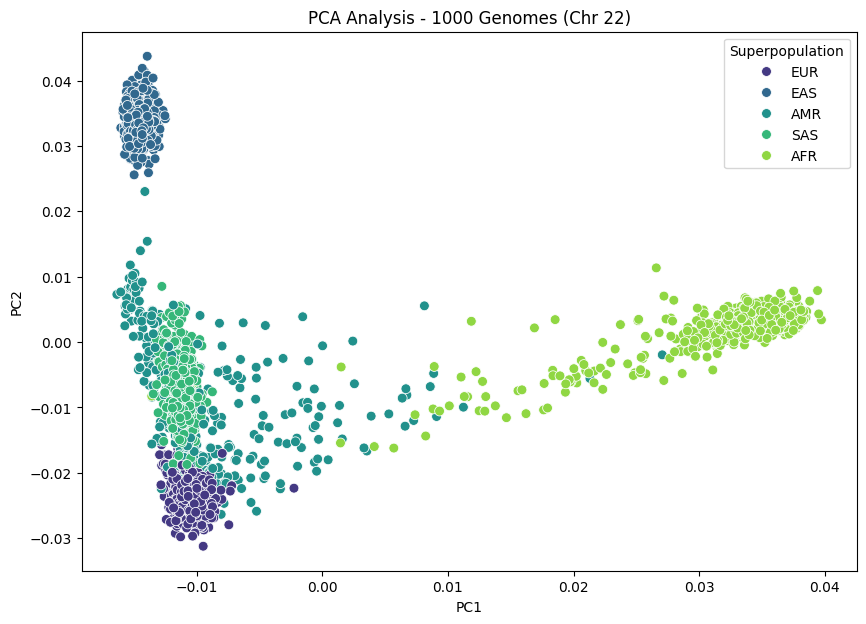

In [28]:

# 4. Graph
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_final, x='PC1', y='PC2', hue='Superpopulation', palette='viridis', s=50)
plt.title('PCA Analysis - 1000 Genomes (Chr 22)')
plt.show()

Now ADMIXTURE Analysis

In [36]:
!head -n 5 chr22.bim

22	.	0	10516173	G	A
22	.	0	10522217	A	G
22	.	0	10526445	A	G
22	.	0	10527034	T	G
22	.	0	10527038	G	C


In [44]:
!./plink --bfile chr22 \
      --set-missing-var-ids @:# \
      --make-bed \
      --out chr22_fixed

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr22_fixed.log.
Options in effect:
  --bfile chr22
  --make-bed
  --out chr22_fixed
  --set-missing-var-ids @:#

8192 MB RAM detected; reserving 4096 MB for main workspace.
993881 variants loaded from .bim file.
993881 missing IDs set.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr22_fixed.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
993881 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--make-bed to 

In [45]:
!head chr22_fixed.bim

22	22:10516173	0	10516173	G	A
22	22:10522217	0	10522217	A	G
22	22:10526445	0	10526445	A	G
22	22:10527034	0	10527034	T	G
22	22:10527038	0	10527038	G	C
22	22:10527074	0	10527074	G	A
22	22:10530662	0	10530662	G	A
22	22:10530667	0	10530667	A	G
22	22:10530699	0	10530699	G	A
22	22:10530754	0	10530754	C	A


In [47]:
!./plink --bfile chr22_fixed \
      --maf 0.05 \
      --make-bed \
      --out chr22_maf

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr22_maf.log.
Options in effect:
  --bfile chr22_fixed
  --maf 0.05
  --make-bed
  --out chr22_maf

8192 MB RAM detected; reserving 4096 MB for main workspace.
993881 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr22_maf.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
896146 variants removed due to minor allele threshold(s)
(--maf/--max-maf/--mac/--max-mac).
97735 variants and 2548 people pass filters

In [48]:
!./plink --bfile chr22_maf \
      --indep-pairwise 50 5 0.1 \
      --out chr22_pruned

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr22_pruned.log.
Options in effect:
  --bfile chr22_maf
  --indep-pairwise 50 5 0.1
  --out chr22_pruned

8192 MB RAM detected; reserving 4096 MB for main workspace.
97735 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr22_pruned.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
97735 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
Pruned 93412 variants from chromosome 22, leav

In [53]:
!./plink --bfile chr22_maf --extract chr22_pruned.prune.in --make-bed --out chr22_ld

PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to chr22_ld.log.
Options in effect:
  --bfile chr22_maf
  --extract chr22_pruned.prune.in
  --make-bed
  --out chr22_ld

8192 MB RAM detected; reserving 4096 MB for main workspace.
97735 variants loaded from .bim file.
2548 people (0 males, 0 females, 2548 ambiguous) loaded from .fam.
Ambiguous sex IDs written to chr22_ld.nosex .
--extract: 4323 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 2548 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is exactly 1.
4323 variants and 2548 people pass filters and QC.
Note: No phenotypes present.
--ma

In [54]:
!./admixture chr22_ld.bed 6

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x4323
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 18.799	Loglikelihood: -1.15304e+07	(delta): 4.95069e+06
2 (EM) 	Elapsed: 21.403	Loglikelihood: -1.1248e+07	(delta): 282446
3 (EM) 	Elapsed: 21.308

In [55]:
import os
os.cpu_count()

8

In [62]:
!./admixture -j6 chr22_ld.bed 2

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x4323
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 1.31	Loglikelihood: -1.14765e+07	(delta): 7.64427e+06
2 (EM) 	Elapsed: 1.215	Loglikelihood: -1.

In [59]:
!./admixture -j6 chr22_ld.bed 3

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x4323
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 2.139	Loglikelihood: -1.15711e+07	(delta): 6.25577e+06
2 (EM) 	Elapsed: 2.08	Loglikelihood: -1.

In [56]:
!./admixture -j6 chr22_ld.bed 4

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x4323
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 2.67	Loglikelihood: -1.15662e+07	(delta): 5.6417e+06
2 (EM) 	Elapsed: 2.468	Loglikelihood: -1.1

In [57]:
!./admixture -j6 chr22_ld.bed 5

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x4323
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 5.773	Loglikelihood: -1.15513e+07	(delta): 5.20523e+06
2 (EM) 	Elapsed: 8.071	Loglikelihood: -1

In [ ]:
!./admixture -j6 chr22_ld.bed 7

****                   ADMIXTURE Version 1.3.0                  ****
****                    Copyright 2008-2015                     ****
****           David Alexander, Suyash Shringarpure,            ****
****                John  Novembre, Ken Lange                   ****
****                                                            ****
****                 Please cite our paper!                     ****
****   Information at www.genetics.ucla.edu/software/admixture  ****

Parallel execution requested.  Will use 6 threads.
Random seed: 43
Point estimation method: Block relaxation algorithm
Convergence acceleration algorithm: QuasiNewton, 3 secant conditions
Point estimation will terminate when objective function delta < 0.0001
Estimation of standard errors disabled; will compute point estimates only.
Size of G: 2548x4323
Performing five EM steps to prime main algorithm
1 (EM) 	Elapsed: 5.936	Loglikelihood: -1.15192e+07	(delta): 4.81092e+06
2 (EM) 	Elapsed: 5.853	Loglikelihood: -1

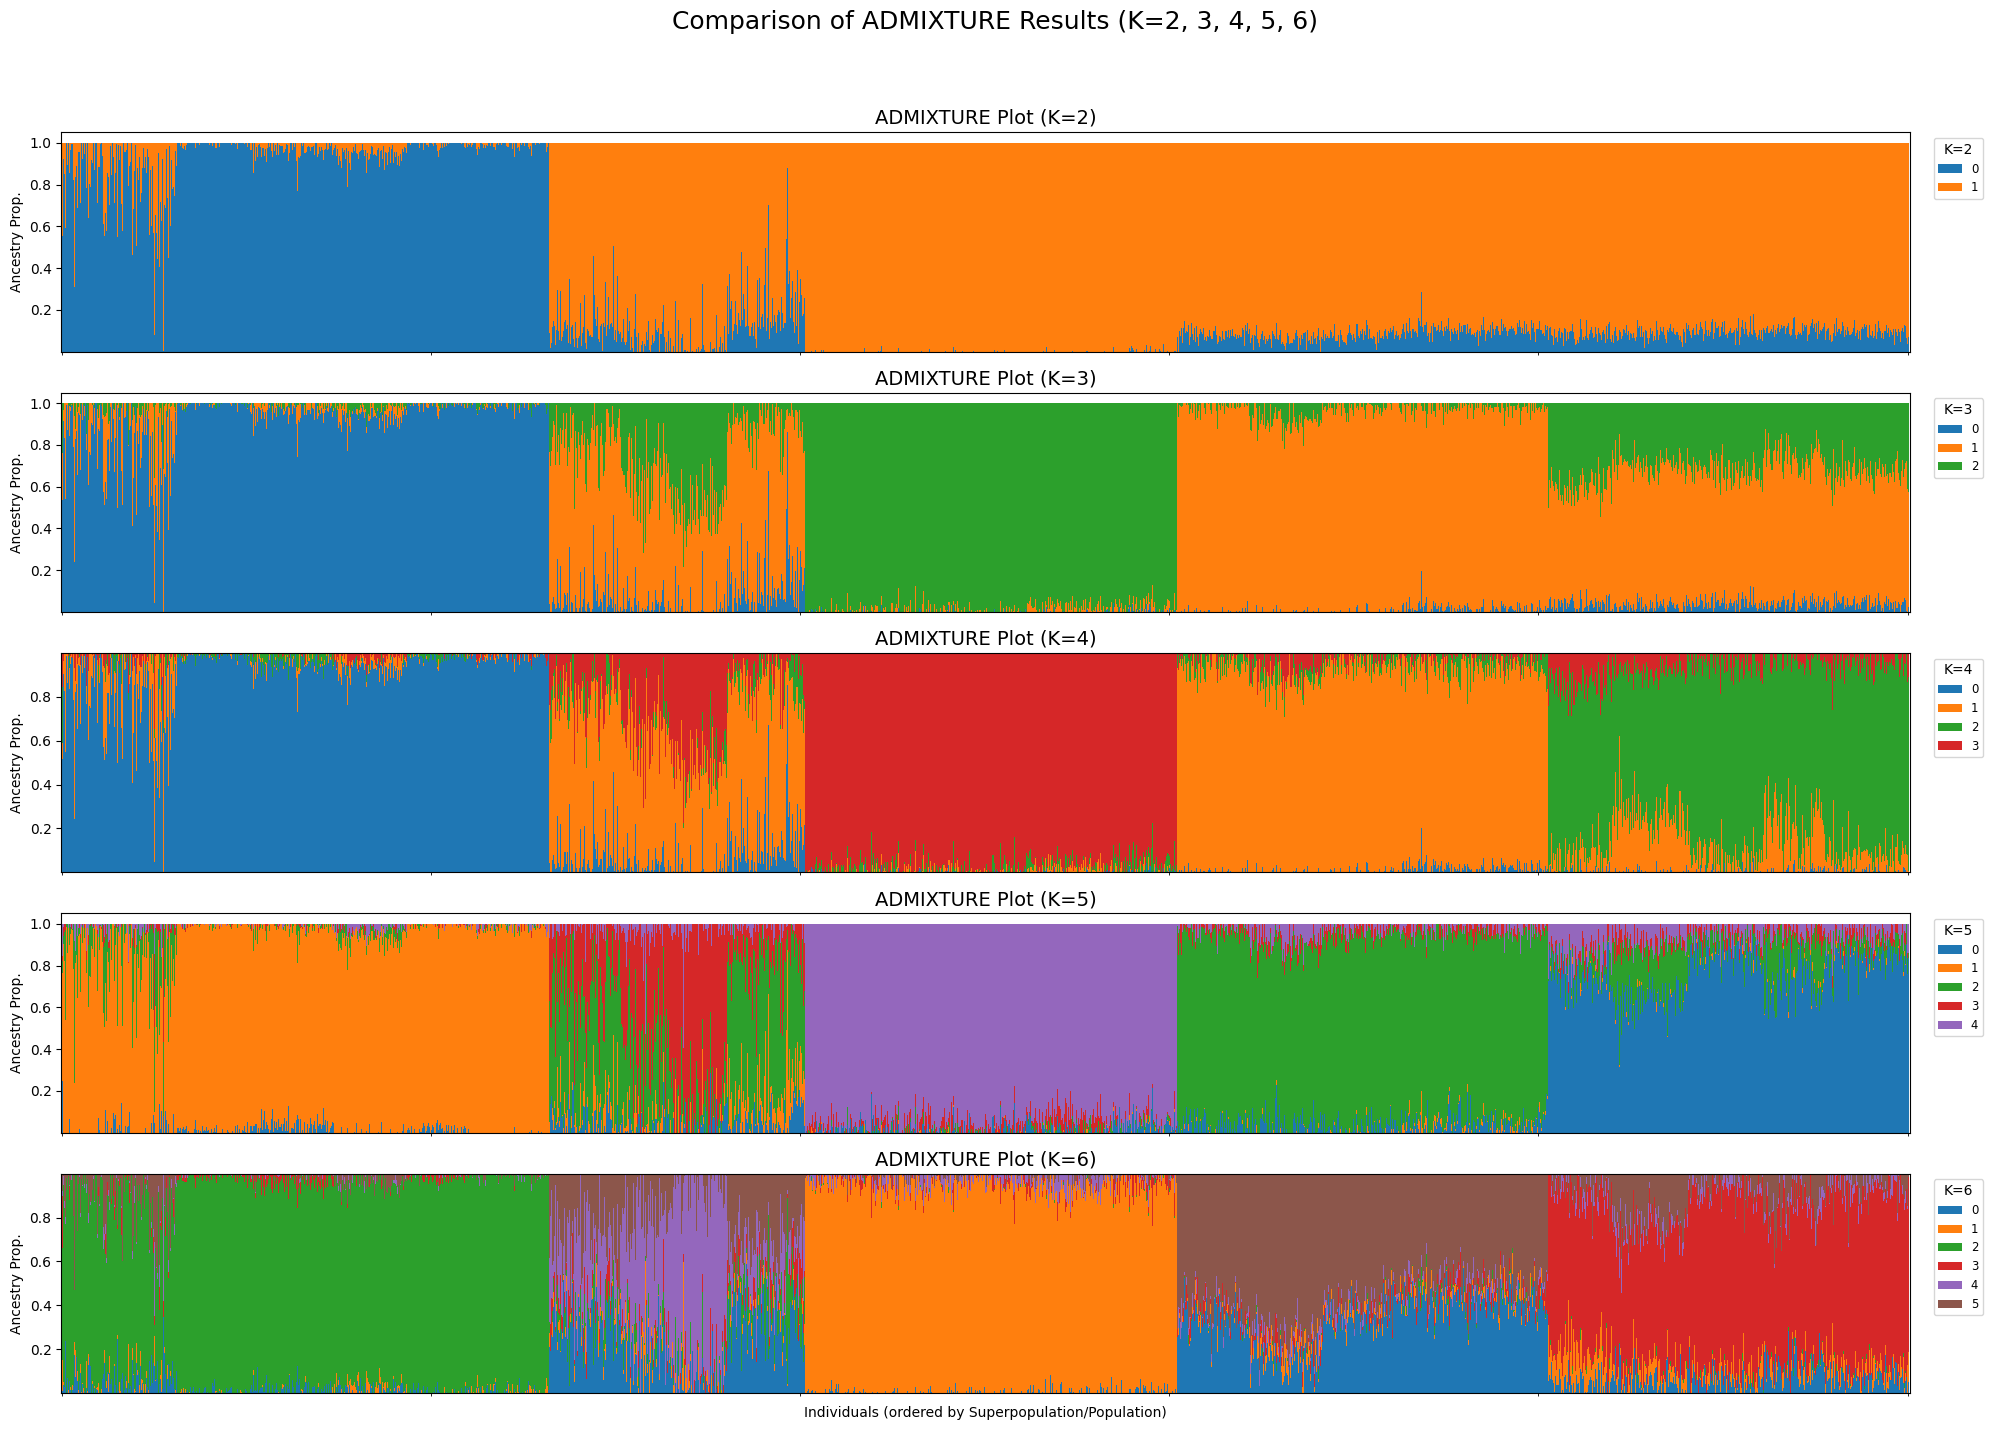

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

k_list = [2, 3, 4, 5, 6, 7]

# 2. load common files (MetaData and FAM)
fam_data = pd.read_csv('chr22_ld.fam', sep=r'\s+', header=None)
meta = pd.read_csv('sample_type.csv')

# Figure
fig, axes = plt.subplots(nrows=len(k_list), ncols=1, figsize=(20, 15), sharex=True)

# Loop 
for i, k in enumerate(k_list):
    filename = f'chr22_ld.{k}.Q'
    
    # Load proportions
    q_data = pd.read_csv(filename, sep=r'\s+', header=None)
    q_data['sample'] = fam_data[1]
    
    # Merge 
    df_merged = pd.merge(q_data, meta, on='sample')
    
    # Order
    df_merged = df_merged.sort_values(by=['Superpopulation', 'Population'])
    
    # Select
    proportions = df_merged[list(range(k))]
    
    # Graph
    proportions.plot(kind='bar', stacked=True, width=1.0, ax=axes[i], edgecolor='none', legend=False)
    
    axes[i].set_title(f'ADMIXTURE Plot (K={k})', fontsize=14)
    axes[i].set_ylabel('Ancestry Prop.')
    axes[i].set_xticks([]) 
    
    # Legends
    axes[i].legend(title=f"K={k}", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small')

# Title
plt.suptitle('Comparison of ADMIXTURE Results (K=2, 3, 4, 5, 6)', fontsize=18)
plt.xlabel('Individuals (ordered by Superpopulation/Population)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 

plt.show()

Looking at the graphs, from K = 2 to K = 3 there is a better classification, but going with a higher K there is not a real improvement, probably due to the fact that the filtering I used was quite stringent, leaving only 4323 SNPs, so the categorization might be limited. 